<a href="https://colab.research.google.com/github/Aggarwal164/Super-Mart-Grocery-Sales/blob/main/supermart_grocery_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Supermart Grocery Sales - Retail Analytics Dataset.csv')
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [ ]:
df.isnull().sum()

,0
Order ID,0
Customer Name,0
Category,0
Sub Category,0
City,0
Order Date,0
Region,0
Sales,0
Discount,0
Profit,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Order Date'].head(10)

,Order Date
0,11-08-2017
1,11-08-2017
2,06-12-2017
3,10-11-2016
4,10-11-2016
5,06-09-2015
6,06-09-2015
7,06-09-2015
8,06-09-2015
9,06-09-2015


In [ ]:
df['Order Date'] = df['Order Date'].astype(str).str.strip()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)

In [ ]:
df['Order Date'].isna().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Order ID,object
Customer Name,object
Category,object
Sub Category,object
City,object
Order Date,datetime64[ns]
Region,object
Sales,int64
Discount,float64
Profit,float64


In [ ]:
df['Order Day'] = df['Order Date'].dt.day
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [ ]:
df['Profit_Margin'] = df['Profit'] / df['Sales']


In [ ]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year,Profit_Margin
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,0.32
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,11,8,2017,0.20
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,0.07
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-11-10,South,896,0.25,89.60,Tamil Nadu,10,11,2016,0.10
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-11-10,South,2355,0.26,918.45,Tamil Nadu,10,11,2016,0.39


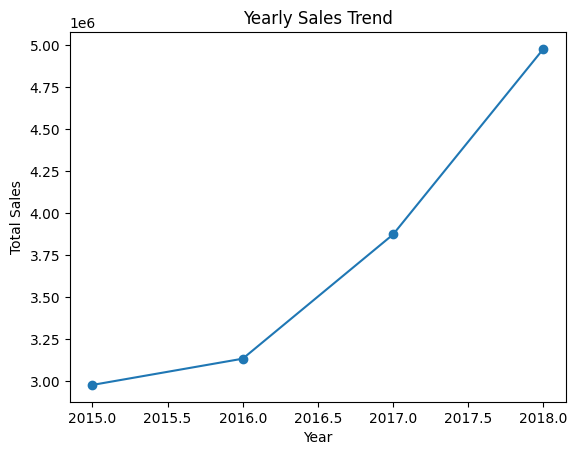

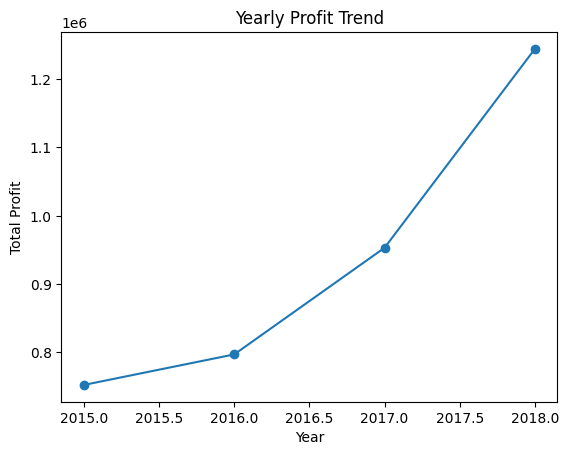

In [ ]:
# yearly treand
yearly_sales = df.groupby('Order Year')['Sales'].sum()
yearly_profit = df.groupby('Order Year')['Profit'].sum()

plt.figure()
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

plt.figure()
plt.plot(yearly_profit.index, yearly_profit.values, marker='o')
plt.title("Yearly Profit Trend")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()

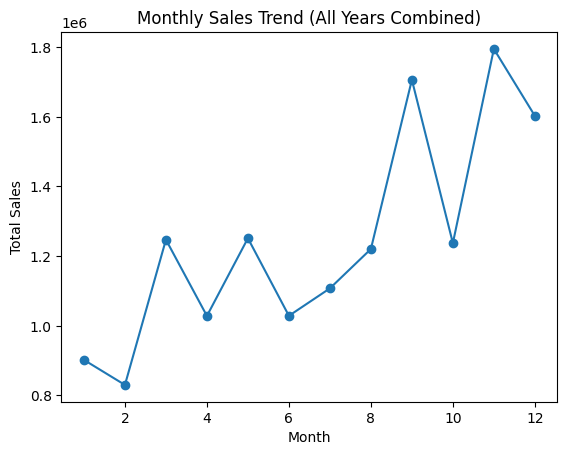

In [ ]:
# monthly tread
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

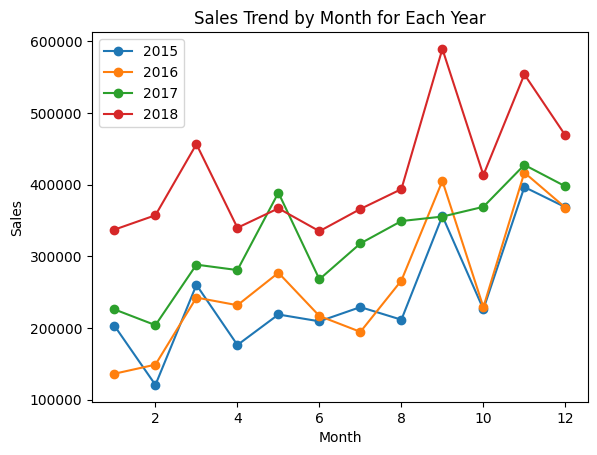

In [ ]:
# year monthly trend

year_month_sales = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()

plt.figure()
for year in year_month_sales['Order Year'].unique():
    temp = year_month_sales[year_month_sales['Order Year'] == year]
    plt.plot(temp['Order Month'], temp['Sales'], marker='o', label=year)

plt.title("Sales Trend by Month for Each Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [ ]:
df = df.drop(columns=['Order Date','Customer Name', 'Order ID'] )

In [ ]:
df.head()

,Category,Sub Category,City,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year,Profit_Margin
0,Oil & Masala,Masalas,Vellore,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,0.32
1,Beverages,Health Drinks,Krishnagiri,South,749,0.18,149.80,Tamil Nadu,11,8,2017,0.20
2,Food Grains,Atta & Flour,Perambalur,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,0.07
3,Fruits & Veggies,Fresh Vegetables,Dharmapuri,South,896,0.25,89.60,Tamil Nadu,10,11,2016,0.10
4,Food Grains,Organic Staples,Ooty,South,2355,0.26,918.45,Tamil Nadu,10,11,2016,0.39


In [ ]:
df['Sales_Lag_1'] = df['Sales'].shift(1)
df['Sales_Lag_7'] = df['Sales'].shift(7)
df['Sales_Lag_30'] = df['Sales'].shift(30)


In [ ]:
df.head()

,Category,Sub Category,City,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year,Profit_Margin,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30
0,Oil & Masala,Masalas,Vellore,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,0.32,NaN,NaN,NaN
1,Beverages,Health Drinks,Krishnagiri,South,749,0.18,149.80,Tamil Nadu,11,8,2017,0.20,1254.0,NaN,NaN
2,Food Grains,Atta & Flour,Perambalur,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,0.07,749.0,NaN,NaN
3,Fruits & Veggies,Fresh Vegetables,Dharmapuri,South,896,0.25,89.60,Tamil Nadu,10,11,2016,0.10,2360.0,NaN,NaN
4,Food Grains,Organic Staples,Ooty,South,2355,0.26,918.45,Tamil Nadu,10,11,2016,0.39,896.0,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Category,0
Sub Category,0
City,0
Region,0
Sales,0
Discount,0
Profit,0
State,0
Order Day,0
Order Month,0


In [ ]:
df['Sales_Rolling_7'] = df['Sales'].rolling(7).mean()
df['Sales_Rolling_30'] = df['Sales'].rolling(30).mean()


In [ ]:
df.head()

,Category,Sub Category,City,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year,Profit_Margin,Sales_Lag_1,Sales_Lag_7,Sales_Lag_30,Sales_Rolling_7,Sales_Rolling_30
0,Oil & Masala,Masalas,Vellore,North,1254,0.12,401.28,Tamil Nadu,11,8,2017,0.32,NaN,NaN,NaN,NaN,NaN
1,Beverages,Health Drinks,Krishnagiri,South,749,0.18,149.80,Tamil Nadu,11,8,2017,0.20,1254.0,NaN,NaN,NaN,NaN
2,Food Grains,Atta & Flour,Perambalur,West,2360,0.21,165.20,Tamil Nadu,6,12,2017,0.07,749.0,NaN,NaN,NaN,NaN
3,Fruits & Veggies,Fresh Vegetables,Dharmapuri,South,896,0.25,89.60,Tamil Nadu,10,11,2016,0.10,2360.0,NaN,NaN,NaN,NaN
4,Food Grains,Organic Staples,Ooty,South,2355,0.26,918.45,Tamil Nadu,10,11,2016,0.39,896.0,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Category,0
Sub Category,0
City,0
Region,0
Sales,0
Discount,0
Profit,0
State,0
Order Day,0
Order Month,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(9964, 17)

In [ ]:
# creating x and y
X = df.drop(columns=['Sales'])
y = df['Sales']

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(transformers=[
('num', StandardScaler(), num_cols),
('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Discount', 'Profit', 'Profit_Margin', 'Sales_Lag_1', 'Sales_Lag_7',
       'Sales_Lag_30', 'Sales_Rolling_7', 'Sales_Rolling_30'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Category', 'Sub Category', 'City', 'Region', 'State'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score


y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print('r2:',r2)
print('mse:',mean_squared_error(y_test, y_pred))
print('rmse:',rmse)

r2: 0.8155870605704141
mse: 59054.73575514138
rmse: 243.0118016787279


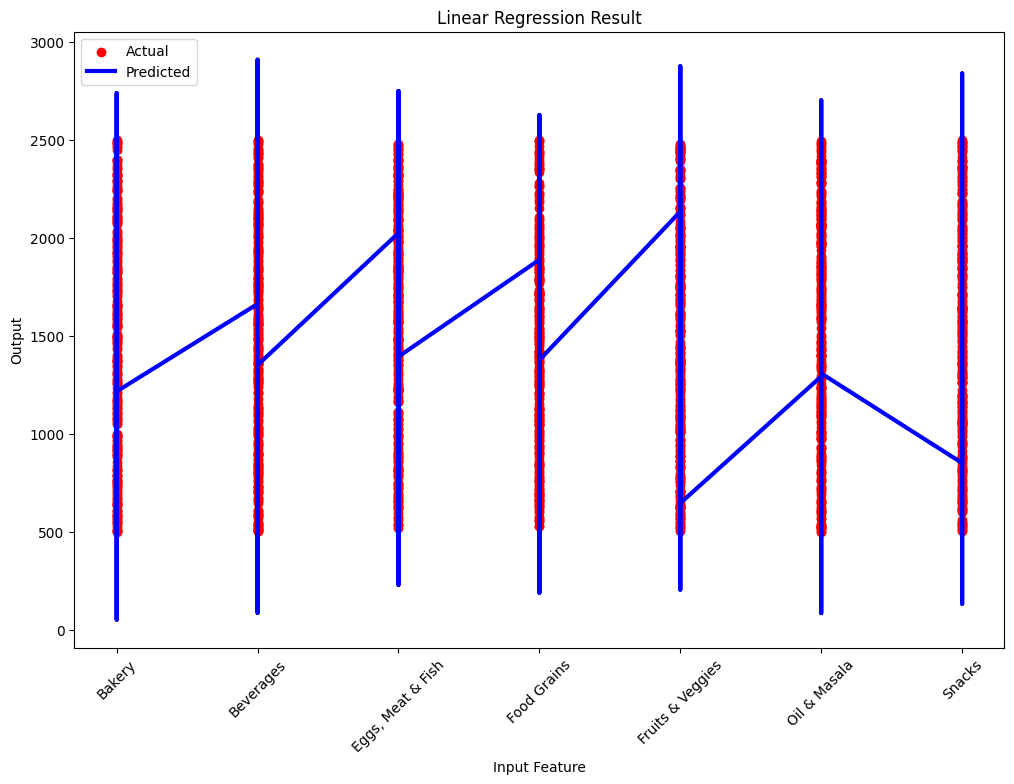

In [ ]:
# visualize the result

x = X_test.iloc[:, 0]

# sort values so the line is straight
order = x.argsort()
x = x.iloc[order]
y_test_sorted = y_test.iloc[order]
y_pred_sorted = y_pred[order]

# plot
plt.figure(figsize=(12, 8))
plt.scatter(x, y_test_sorted,color='red', label='Actual')
plt.plot(x, y_pred_sorted,color='blue', linewidth=3, label='Predicted')

plt.xlabel('Input Feature')
plt.ylabel('Output')
plt.title('Linear Regression Result')
plt.xticks(rotation=45)
plt.legend()
plt.show()

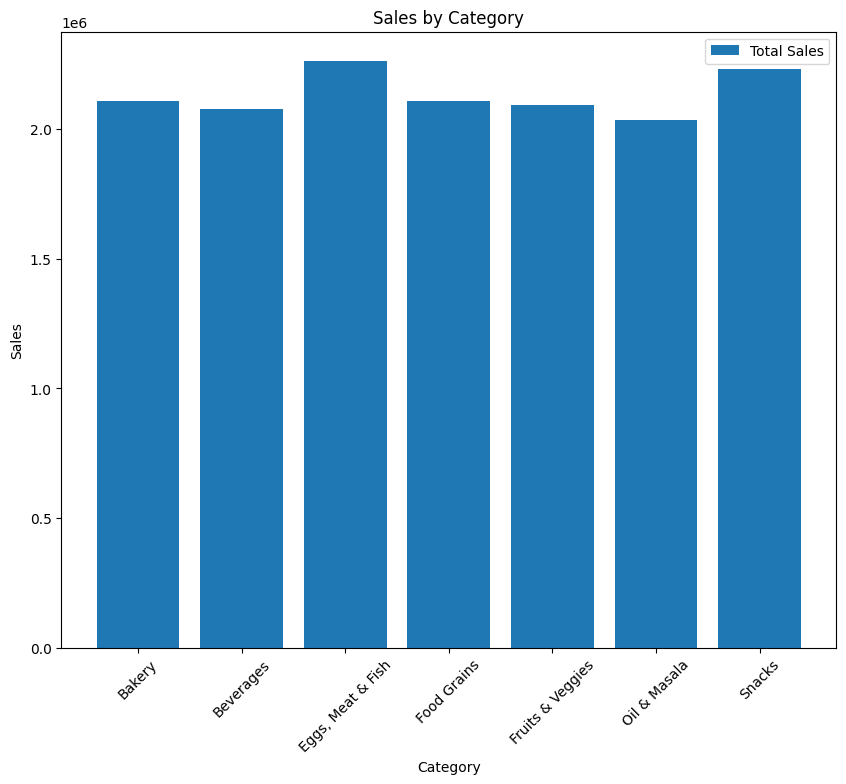

In [ ]:
# sales by category

category_sales = df.groupby('Category')['Sales'].sum()


plt.figure(figsize=(10,8))
plt.bar(category_sales.index, category_sales.values, label='Total Sales')

plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Sales by Category')
plt.xticks(rotation=45)
plt.legend()
plt.show()

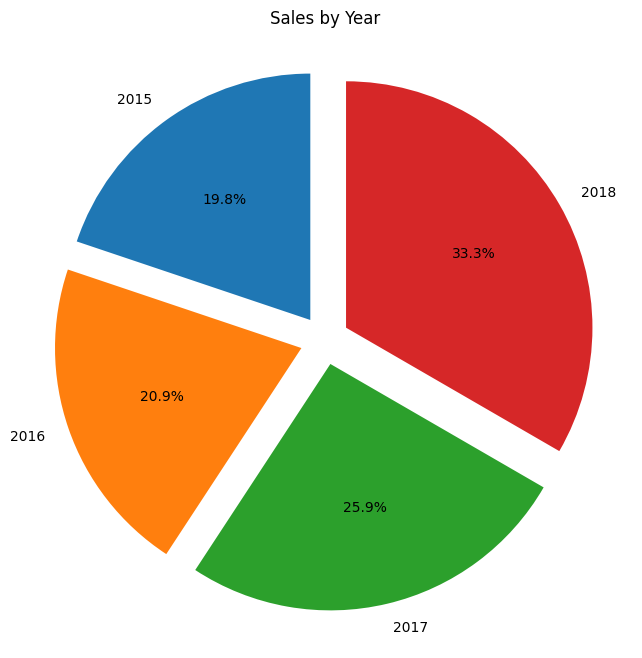

In [ ]:
# sales by year

year_sales = df.groupby('Order Year')['Sales'].sum()

plt.figure(figsize=(10,8))
plt.pie(year_sales, labels=year_sales.index, autopct='%1.1f%%',
        explode=[0.1] * len(year_sales),startangle=90)
plt.title('Sales by Year')
plt.show()

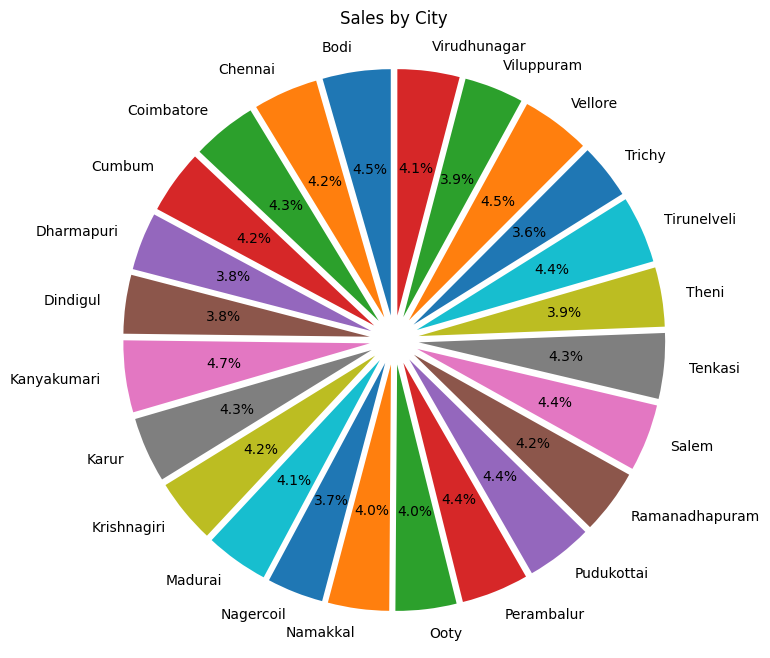

In [ ]:
# sales by city

city_sales = df.groupby('City')['Sales'].sum()

# plot pie chart
plt.figure(figsize=(10,8))
plt.pie(city_sales.values,labels=city_sales.index,
    autopct='%1.1f%%',
    explode=[0.1] * len(city_sales),
    startangle=90
)
plt.title('Sales by City')
plt.show()
